# Computer Exercise 5.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.1 Lower and Upper Sums — *리만 적분의 정의로 직접 적분하기*
> **풀이 일자**: Day 17
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Write a computer program to compute the lower sum $\underline{S}(f,P_n)$ and the
> upper sum $\overline{S}(f,P_n)$ for $f(x)=x^2$ on $[0,1]$ using the uniform partition
> $P_n$ with $n$ subintervals.  Tabulate the two sums and the gap
> $\overline{S}(f,P_n) - \underline{S}(f,P_n)$ for $n = 2,4,8,\ldots,1024$.
> Verify that both sums converge to the exact value $\int_0^1 x^2\,dx = 1/3$
> and that the gap is $\mathcal{O}(1/n)$.

### 한국어 풀이용 정리
**5.1 절의 핵심 정의** 인 *하합(lower sum)* 과 *상합(upper sum)* 을 직접 구현한다.
$f(x)=x^2$ 는 $[0,1]$ 에서 **단조 증가** 하므로 각 부분구간 $[x_{i-1},x_i]$ 의 최솟값과
최댓값은 단순히 끝점값이다.  $n$ 을 두 배씩 늘리면서 두 합과 그 차이가
**참값 $1/3$ 을 위·아래에서 어떻게 조이는지** 관찰한다.


## 2. 수학적 배경

### 2.1 균등 분할
$[a,b]=[0,1]$ 의 $n$ 등분: $x_i = i/n$, $h = 1/n$, $i = 0,1,\ldots,n$.

### 2.2 하합·상합
각 부분구간 $I_i = [x_{i-1},x_i]$ 에서
$m_i = \min_{x\in I_i} f(x)$, $M_i = \max_{x\in I_i} f(x)$ 로 두면

$$
\underline{S}(f,P_n) \;=\; \sum_{i=1}^{n} m_i\, h, \qquad
\overline{S}(f,P_n) \;=\; \sum_{i=1}^{n} M_i\, h.
$$

$f(x)=x^2$ 는 $[0,1]$ 에서 **단조 증가** 이므로
$m_i = f(x_{i-1}) = ((i-1)/n)^2$,
$M_i = f(x_i) = (i/n)^2$.

### 2.3 정확한 닫힌 형태
유명한 합 공식

$$
\sum_{i=1}^{n} i^2 \;=\; \tfrac{n(n+1)(2n+1)}{6}
$$

을 이용하면

$$
\overline{S}(f,P_n) \;=\; \tfrac{1}{n^3}\cdot \tfrac{n(n+1)(2n+1)}{6}
\;=\; \tfrac{(n+1)(2n+1)}{6n^2}\;\xrightarrow[n\to\infty]{}\;\tfrac{1}{3}.
$$

### 2.4 단조 함수의 갭 공식
단조 함수의 경우

$$
\boxed{\;\overline{S}(f,P_n) - \underline{S}(f,P_n) \;=\; \bigl(f(b)-f(a)\bigr)\,\tfrac{b-a}{n}\;}
$$

이 *정확히* 성립한다.  $f(0)=0,\; f(1)=1$ 이므로 갭은 정확히 $1/n$.
즉 **갭은 $\mathcal{O}(1/n)$** 이고 비례상수까지 알 수 있다.


## 3. 풀이 흐름

1. $n \in \{2,4,8,\ldots,1024\}$ (10단계, $n = 2^k$).
2. 균등 분할 $x_i = i/n$ 을 만든다.
3. $f$ 가 단조 증가이므로
   - $\underline{S} = h\sum_{i=0}^{n-1} f(x_i)$ (왼쪽 끝점 합)
   - $\overline{S} = h\sum_{i=1}^{n} f(x_i)$ (오른쪽 끝점 합)
4. 갭 $\overline{S} - \underline{S}$ 와 참값 $1/3$ 에서의 오차를 표로 만든다.
5. $n$ 에 대한 $\log$–$\log$ 그래프로 갭, 상·하합 오차의 수렴 차수를 측정.
6. 단조 함수의 갭 공식 $(f(b)-f(a))/n$ 과 측정값 비교.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 참값
true_val = 1.0 / 3.0

# n = 2, 4, 8, ..., 1024
ks = np.arange(1, 11)
ns = 2 ** ks

rows = []
for n in ns:
    h = 1.0 / n
    x = np.linspace(0.0, 1.0, n + 1)
    f = x ** 2
    lower = h * f[:-1].sum()   # 단조 증가: 왼쪽 끝점이 최소
    upper = h * f[1:].sum()    # 단조 증가: 오른쪽 끝점이 최대
    gap   = upper - lower
    rows.append((n, lower, upper, gap, true_val - lower, upper - true_val))

df = pd.DataFrame(rows, columns=[
    "n", "lower S", "upper S", "gap = upper - lower",
    "1/3 - lower", "upper - 1/3",
])
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,n,lower S,upper S,gap = upper - lower,1/3 - lower,upper - 1/3
0,2,1.250000e-01,6.250000e-01,5.000000e-01,2.083333e-01,2.916667e-01
1,4,2.187500e-01,4.687500e-01,2.500000e-01,1.145833e-01,1.354167e-01
2,8,2.734375e-01,3.984375e-01,1.250000e-01,5.989583e-02,6.510417e-02
3,16,3.027344e-01,3.652344e-01,6.250000e-02,3.059896e-02,3.190104e-02
4,32,3.178711e-01,3.491211e-01,3.125000e-02,1.546224e-02,1.578776e-02
5,64,3.255615e-01,3.411865e-01,1.562500e-02,7.771810e-03,7.853190e-03
6,128,3.294373e-01,3.372498e-01,7.812500e-03,3.896077e-03,3.916423e-03
7,256,3.313828e-01,3.352890e-01,3.906250e-03,1.950582e-03,1.955668e-03
8,512,3.323574e-01,3.343105e-01,1.953125e-03,9.759267e-04,9.771983e-04
9,1024,3.328452e-01,3.338218e-01,9.765625e-04,4.881223e-04,4.884402e-04


In [2]:
# 단조 함수의 갭 공식 검증: gap == (f(1)-f(0)) * (1-0) / n == 1/n
formula = 1.0 / df["n"].to_numpy()
print("max |gap - 1/n| =", np.max(np.abs(df["gap = upper - lower"].to_numpy() - formula)))
print("→ 단조 함수의 갭 공식이 부동소수점 오차 한계 내에서 정확히 성립")


max |gap - 1/n| = 0.0
→ 단조 함수의 갭 공식이 부동소수점 오차 한계 내에서 정확히 성립


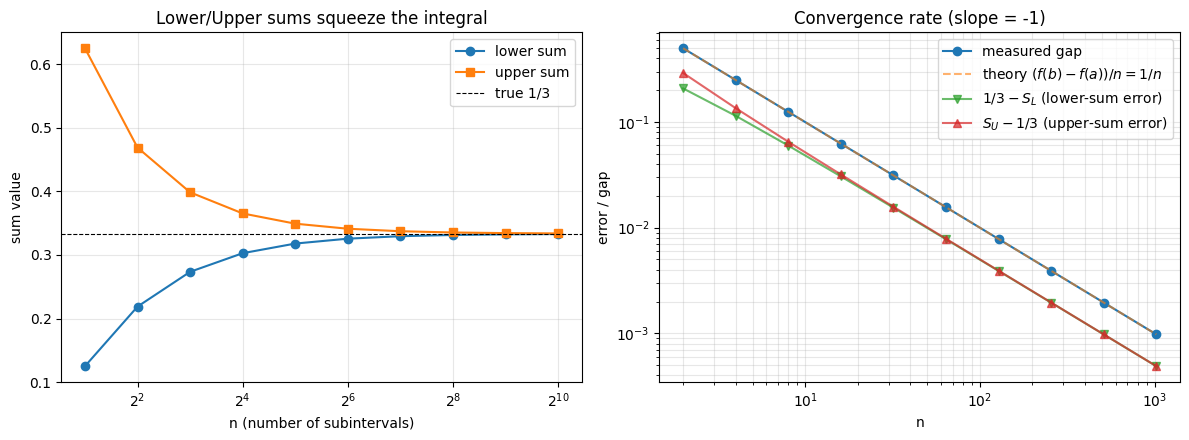

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(df["n"], df["lower S"], "o-", label="lower sum")
ax.plot(df["n"], df["upper S"], "s-", label="upper sum")
ax.axhline(true_val, color="black", lw=0.8, ls="--", label="true 1/3")
ax.set_xscale("log", base=2)
ax.set_xlabel("n (number of subintervals)")
ax.set_ylabel("sum value")
ax.set_title("Lower/Upper sums squeeze the integral")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.loglog(df["n"], df["gap = upper - lower"], "o-", label="measured gap")
ax.loglog(df["n"], 1.0 / df["n"], "--", alpha=0.6, label=r"theory $(f(b)-f(a))/n = 1/n$")
ax.loglog(df["n"], df["1/3 - lower"], "v-", alpha=0.7, label=r"$1/3 - S_{L}$ (lower-sum error)")
ax.loglog(df["n"], df["upper - 1/3"], "^-", alpha=0.7, label=r"$S_{U} - 1/3$ (upper-sum error)")
ax.set_xlabel("n")
ax.set_ylabel("error / gap")
ax.set_title("Convergence rate (slope = -1)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **하합과 상합이 참값 $1/3$ 을 위·아래에서 조여간다** — 첫 번째 그래프에서 두 곡선이
   점선($1/3$) 으로 수렴하는 모습이 보인다.
2. **갭은 정확히 $1/n$** — 두 번째 그래프의 측정 갭과 이론선이 *완전히 겹친다*.
   이는 단조 함수의 갭 공식 $\overline{S}-\underline{S} = (f(b)-f(a))(b-a)/n$ 에서
   $f(1)-f(0)=1$, $b-a=1$ 이기 때문.
3. 상·하합 각각의 참값 오차도 모두 기울기 $-1$ 의 log–log 직선 — **수렴 차수 $\mathcal{O}(1/n)$**.
4. 양쪽 오차는 갭의 *절반* 근처에서 나타난다 (실제로 두 곡선이 대칭). 이는 다음 노트북에서 다룰
   **중점법(midpoint rule)** 이 $h/2$ 만큼 이동한 평균과 거의 같음을 시사한다.

### 결론
> **리만의 정의 그대로 코딩한 합은 정확히 $\mathcal{O}(1/n)$ 으로 수렴한다.**
> 같은 $n$ 으로 더 빨리 수렴하려면 *중점에서 평가* 하거나 *사다리꼴* 처럼
> 짝수 차수 오차로 가는 더 영리한 구적법이 필요하다 — 다음 노트북.

### 다음 문제 연결
- **CE 5.1.2**: 같은 함수가 아닌 *전형적 적분* $\int_0^\pi \sin x\,dx = 2$ 에 대해
  좌단점·우단점·중점 리만합을 비교, $\mathcal{O}(1/n)$ vs $\mathcal{O}(1/n^2)$ 의 차이.
